In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os

# kaggle input 폴더 안에 뭐가 있는지 전부 출력
print(os.listdir("/kaggle/input"))

['competitions']


In [4]:
import os

base_path = "/kaggle/input"
print(os.listdir(base_path))

['competitions']


In [6]:
import os

# 데이터 폴더 안에 뭐가 있는지 확인
base_path ="/kaggle/input/competitions/cassava-leaf-disease-classification"
print(os.listdir(base_path))
# ['train_images', 'test_images', 'train.csv', 'label_num_to_disease_map.json'] 뜨면 정상

['train_tfrecords', 'sample_submission.csv', 'test_tfrecords', 'label_num_to_disease_map.json', 'train_images', 'train.csv', 'test_images']


In [7]:
import pandas as pd

df = pd.read_csv(f"{base_path}/train.csv")

print(df.head())
print(df.shape)
print(df['label'].value_counts())

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3
(21397, 2)
label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64


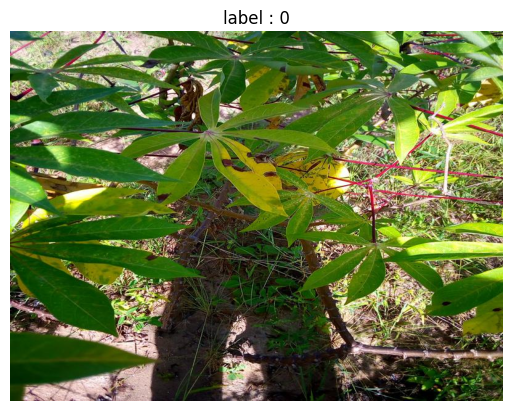

이미지 크기 : (800, 600)
라벨 : 0


In [10]:
from PIL import Image
import matplotlib.pyplot as plt

sample_filename = df['image_id'][0]
sample_label = df['label'][0]

img_path = f"{base_path}/train_images/{sample_filename}"

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.title(f"label : {sample_label}")
plt.show()

print(f"이미지 크기 : {img.size}")
print(f"라벨 : {sample_label}")

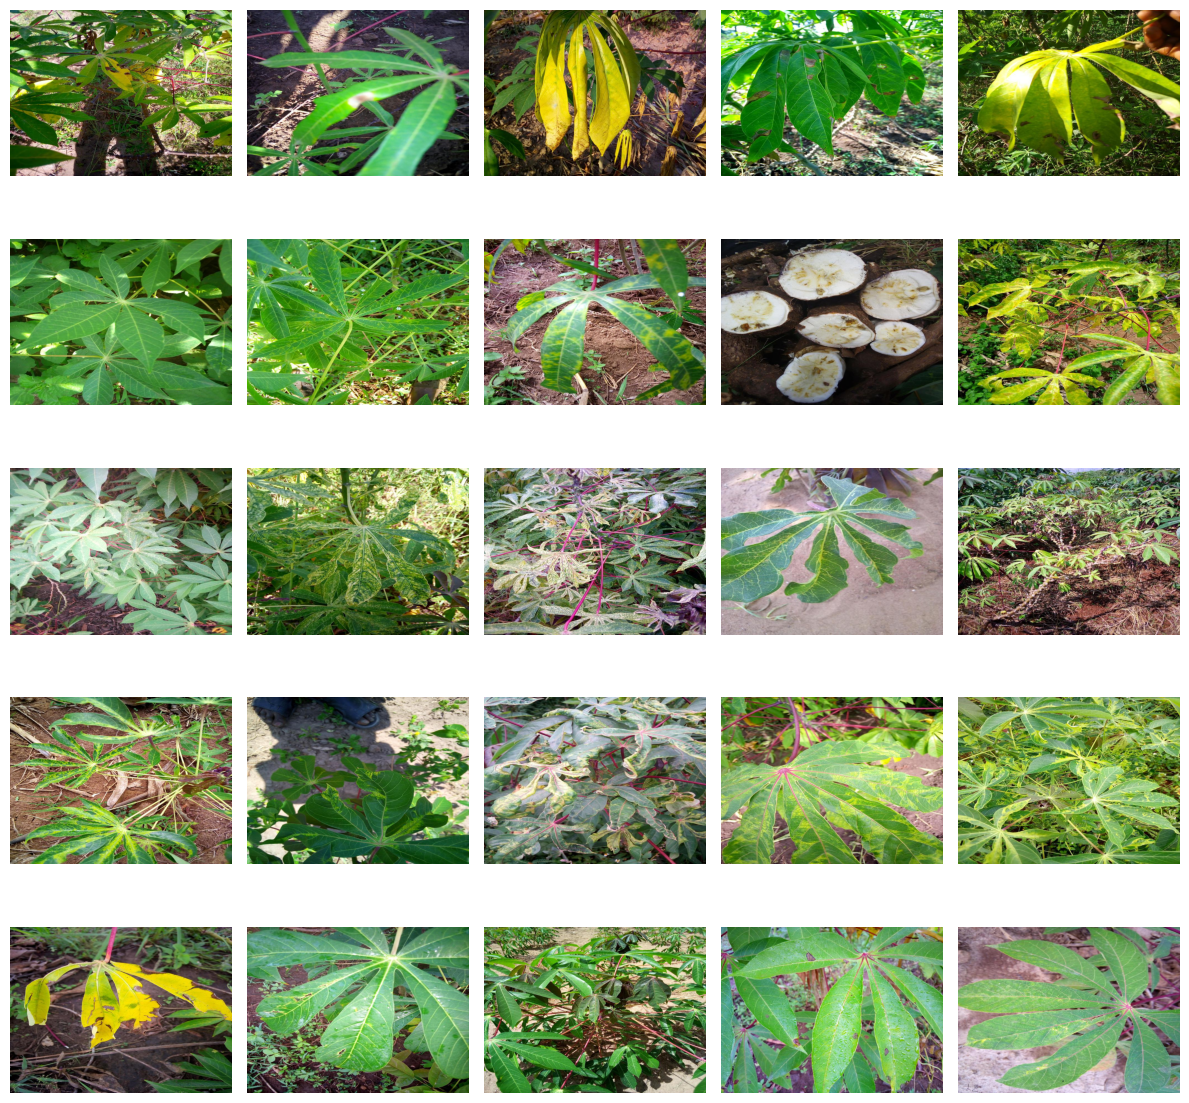

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
# 5행 5열 격자로 이미지 출력할 공간 만들기

for class_idx in range(5):
    # 해당 클래스 이미지만 필터링
    class_df = df[df['label'] == class_idx]

    for img_idx in range(5):
        # 클래스별로 5장씩 가져오기
        filename = class_df.iloc[img_idx]['image_id']
        img_path = f"{base_path}/train_images/{filename}"
        img = Image.open(img_path)

        # 격자 위치에 이미지 그리기
        ax = axes[class_idx][img_idx]
        ax.imshow(img)
        ax.axis('off')

        # 첫 번째 열에만 클래스 번호 표시
        if img_idx == 0:
            ax.set_ylabel(f"class {class_idx}", fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

base_path ="/kaggle/input/competitions/cassava-leaf-disease-classification"
df = pd.read_csv(f"{base_path}/train.csv")

print(df.shape)                        # 전체 데이터 수
print("\n클래스별 이미지 수:")
print(df['label'].value_counts())      # 클래스별 분포

(21397, 2)

클래스별 이미지 수:
label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64


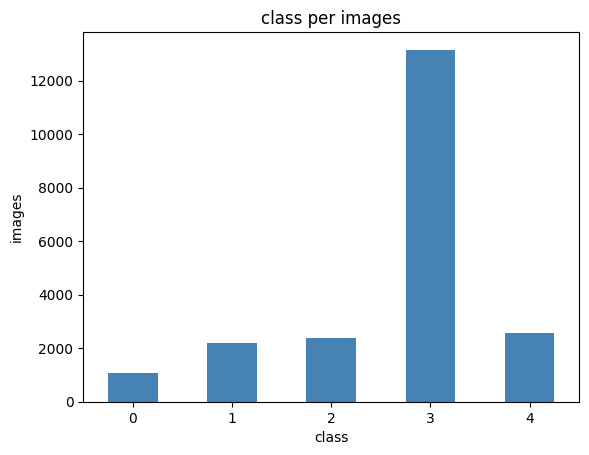

In [16]:
import matplotlib.pyplot as plt

df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("class per images")
plt.xlabel("class")
plt.ylabel("images")
plt.xticks(rotation=0)
plt.show()